# Treino EDSR-Baseline (Enhanced Deep Residual Networks)

**Referência:** Lim et al., 2017 - "Enhanced Deep Residual Networks for Single Image Super-Resolution"

Este notebook contém apenas o treino do modelo EDSR-Baseline (16 blocos residuais, 64 filtros, sem BatchNorm). Para análise exploratória dos dados e comparação com outros modelos, veja `00_guia_analise_comparacao.ipynb`.

## Setup e Configurações

In [1]:
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

sys.path.append(".")

from datasets import SRDataset, SRBenchmarkDataset, SREvalDataset
from models import EDSRBaseline
from metrics import calc_psnr, calc_ssim
from train import fit, evaluate

/mnt/storage_C4/marcos_melo/ml2/upscaling-ml/.env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configurar seeds para reprodutibilidade
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed fixada: {SEED}")

Seed fixada: 42


In [3]:
# Detectar dispositivo
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}")

Dispositivo: cpu
Torch: 2.11.0+cu128


In [4]:
# Criar diretório de outputs
student_tag = "EDSR_2026-07-05"  # Altere conforme necessário
output_dir = Path("outputs") / student_tag
output_dir.mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(log_dir=str(output_dir / "tensorboard"))

print(f"Output dir: {output_dir}")
print(f"TensorBoard: tensorboard --logdir {output_dir / 'tensorboard'}")

Output dir: outputs/EDSR_2026-07-05
TensorBoard: tensorboard --logdir outputs/EDSR_2026-07-05/tensorboard


## Carregamento de Dados

In [5]:
# Configurações de dataset
PATCH_SIZE = 192  # EDSR usa patches maiores
SCALE = 4
BATCH_SIZE = 16

# Verificar se dados existem
DATA_DIR = Path("datasets")
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Pasta '{DATA_DIR}' não encontrada. Baixe os datasets (DIV2K, Set5, etc.) antes de continuar.")

# Carregar datasets
train_dataset = SRDataset("datasets/DIV2K_train_HR", patch_size=PATCH_SIZE, scale=SCALE)
val_dataset = SRBenchmarkDataset("datasets/Set5/image_SRF_4", scale=SCALE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

print(f"Dataset de treino: {len(train_dataset)} patches")
print(f"Dataset de validação: {len(val_dataset)} imagens")
print(f"Batch size: {BATCH_SIZE} | Patch size: {PATCH_SIZE}x{PATCH_SIZE} | Scale: {SCALE}x")

Dataset de treino: 800 patches
Dataset de validação: 5 imagens
Batch size: 16 | Patch size: 192x192 | Scale: 4x


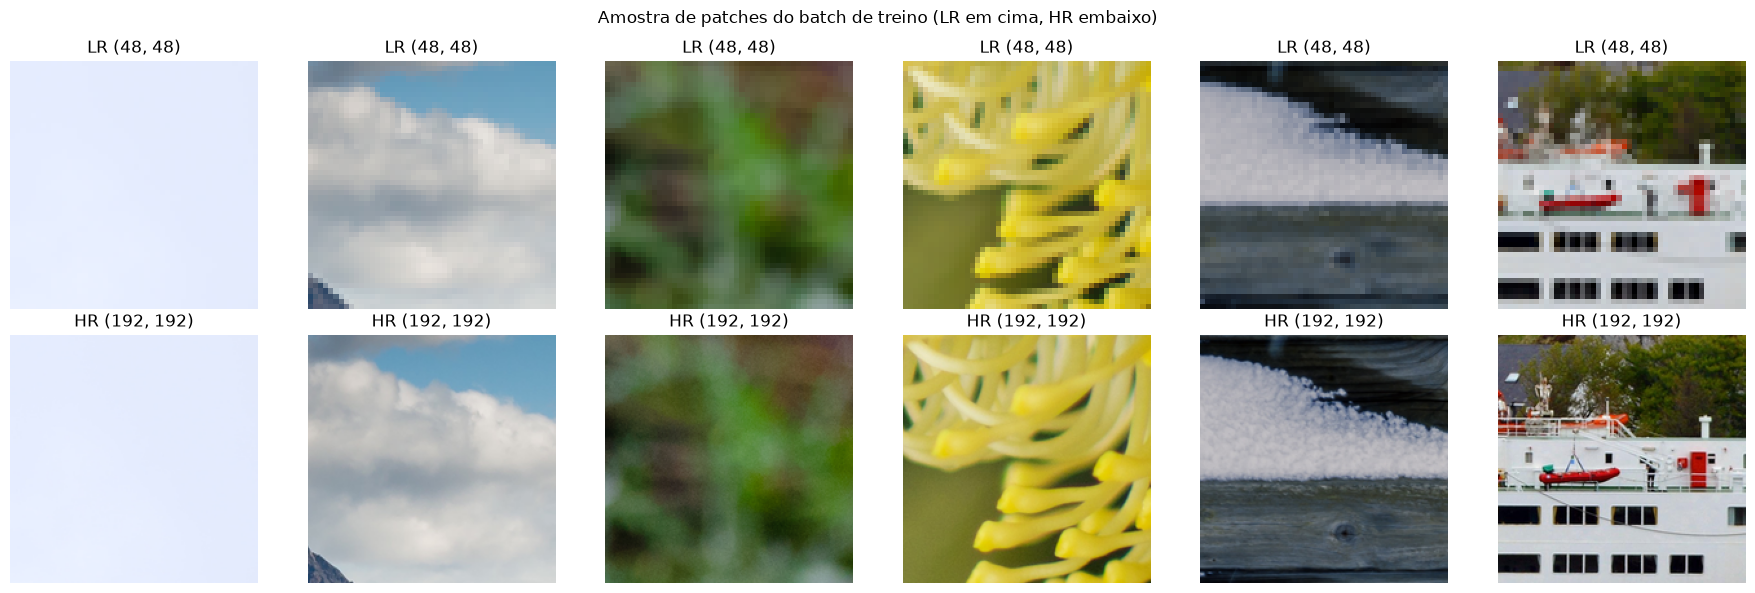

In [6]:
# Visualizar amostra do batch de treino
sample_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)
lr_batch, hr_batch = next(iter(sample_loader))

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i in range(6):
    axes[0, i].imshow(lr_batch[i].permute(1, 2, 0))
    axes[0, i].set_title(f"LR {tuple(lr_batch[i].shape[1:])}")
    axes[0, i].axis("off")

    axes[1, i].imshow(hr_batch[i].permute(1, 2, 0))
    axes[1, i].set_title(f"HR {tuple(hr_batch[i].shape[1:])}")
    axes[1, i].axis("off")

plt.suptitle("Amostra de patches do batch de treino (LR em cima, HR embaixo)")
plt.tight_layout()
plt.savefig(output_dir / "sample_batch.png", dpi=150)
plt.show()

## Treinamento

In [7]:
# Inicializar modelo
model = EDSRBaseline(num_features=64, num_blocks=16, scale=SCALE).to(device)

# Configuração de treino
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.L1Loss()  # EDSR usa L1Loss em vez de MSELoss
n_epochs = 100

print(f"Modelo: {model.__class__.__name__}")
print(f"Parâmetros: {sum(p.numel() for p in model.parameters()):,}")
print(f"Configuração: num_features=64, num_blocks=16, scale={SCALE}")
print(f"Optimizer: Adam (lr=1e-4)")
print(f"Loss: L1Loss")
print(f"Epochs: {n_epochs}")

Modelo: EDSRBaseline
Parâmetros: 1,517,571
Configuração: num_features=64, num_blocks=16, scale=4
Optimizer: Adam (lr=1e-4)
Loss: L1Loss
Epochs: 100


In [8]:
# Treino
edsr_history = fit(
    model, train_loader, val_loader, optimizer, criterion, device,
    epochs=n_epochs, writer=writer, tag="edsr", upscale_input=False
)

print("\nTreinamento concluído!")

Epoch 1/100 | Loss: 0.139148 | Tempo: 87.7s


Epoch 2/100 | Loss: 0.063676 | Tempo: 65.8s


Epoch 3/100 | Loss: 0.053531 | Tempo: 65.4s


Epoch 4/100 | Loss: 0.046178 | Tempo: 65.9s


Epoch 5/100 | Loss: 0.042874 (val: 0.045607) | PSNR: 24.08 dB (bicubic: 26.89 dB) | SSIM: 0.9666 | Tempo: 66.3s


...

Epoch 96/100 | Loss: 0.028672 | Tempo: 65.9s


Epoch 97/100 | Loss: 0.028151 | Tempo: 66.4s


Epoch 98/100 | Loss: 0.028952 | Tempo: 65.6s


Epoch 99/100 | Loss: 0.028653 | Tempo: 65.7s


Epoch 100/100 | Loss: 0.029748 (val: 0.025845) | PSNR: 28.25 dB (bicubic: 26.89 dB) | SSIM: 0.9866 | Tempo: 66.2s

Treinamento concluído!


## Avaliação e Salvamento

In [9]:
# Avaliar em dataset DIV2K_valid_HR
eval_dataset = SREvalDataset("datasets/DIV2K_valid_HR", scale=SCALE)
eval_loader = DataLoader(eval_dataset, batch_size=1, shuffle=False)

val_metrics = evaluate(model, eval_loader, device, upscale_input=False)

print(f"\nResultados em DIV2K_valid:")
print(f"  PSNR (modelo): {val_metrics['psnr_model']:.2f} dB")
print(f"  PSNR (bicubic baseline): {val_metrics['psnr_bicubic']:.2f} dB")
print(f"  SSIM: {val_metrics['ssim_model']:.4f}")
print(f"  Ganho em relação ao bicubic: {val_metrics['psnr_model'] - val_metrics['psnr_bicubic']:+.2f} dB")


Resultados em DIV2K_valid:
  PSNR (modelo): 27.77 dB
  PSNR (bicubic baseline): 26.82 dB
  SSIM: 0.9753
  Ganho em relação ao bicubic: +0.94 dB


In [10]:
# Salvar modelo
model_path = output_dir / "edsr_final.pt"
torch.save(model.state_dict(), model_path)

print(f"Modelo salvo em: {model_path}")

Modelo salvo em: outputs/EDSR_2026-07-05/edsr_final.pt


In [ ]:
# Visualizar resultados com zoom
def tensor_to_img(t):
    return t.detach().squeeze(0).permute(1, 2, 0).cpu().numpy().clip(0, 1)

def get_crop(img, crop_size=150):
    """Recorta uma região central (ou pode ajustar para região de interesse)."""
    h, w, _ = img.shape
    ch, cw = crop_size, crop_size
    y0 = h // 2 - ch // 2
    x0 = w // 2 - cw // 2
    return img[y0:y0+ch, x0:x0+cw]

model.eval()
n_samples = 5
crop_size = 150  # ajuste conforme o tamanho da sua imagem

fig, axes = plt.subplots(n_samples, 4, figsize=(20, 4 * n_samples))

with torch.no_grad():
    for i, (lr_img, hr_img) in enumerate(eval_loader):
        if i >= n_samples:
            break

        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        lr_up = F.interpolate(lr_img, scale_factor=SCALE, mode="bicubic", align_corners=False)
        sr = model(lr_img).clamp(0, 1)

        psnr_bic = calc_psnr(lr_up, hr_img)
        psnr_sr = calc_psnr(sr, hr_img)
        ssim_bic = calc_ssim(lr_up, hr_img)
        ssim_sr = calc_ssim(sr, hr_img)

        hr_np = tensor_to_img(hr_img)
        bic_np = tensor_to_img(lr_up)
        sr_np = tensor_to_img(sr)

        # Imagem completa
        axes[i, 0].imshow(hr_np)
        axes[i, 0].set_title("HR (original)")

        # Zoom (crop ampliado) - usando interpolation="nearest" para ver os pixels reais
        axes[i, 1].imshow(get_crop(hr_np, crop_size), interpolation="nearest")
        axes[i, 1].set_title("HR (zoom)")

        axes[i, 2].imshow(get_crop(bic_np, crop_size), interpolation="nearest")
        axes[i, 2].set_title("Bicubic (zoom)\nPSNR: {:.2f} dB  SSIM: {:.4f}".format(psnr_bic, ssim_bic))

        axes[i, 3].imshow(get_crop(sr_np, crop_size), interpolation="nearest")
        axes[i, 3].set_title("EDSR (zoom)\nPSNR: {:.2f} dB  SSIM: {:.4f}".format(psnr_sr, ssim_sr))

        for ax in axes[i]:
            ax.axis("off")

plt.tight_layout()
plt.savefig(output_dir / "resultados_edsr_zoom.png", dpi=150)
plt.show()